# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('/content/sample_data/foodhub_order.csv')
# returns the first 5 rows
head = df.head()
print(f"Head of the data:\n{head}")

# returns the last 5 rows
tail = df.tail()
print(f"\n\nTail of the data:\n{tail}")

Head of the data:
   order_id  customer_id            restaurant_name cuisine_type  \
0   1477147       337525                    Hangawi       Korean   
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese   
2   1477070        66393                Cafe Habana      Mexican   
3   1477334       106968  Blue Ribbon Fried Chicken     American   
4   1478249        76942           Dirty Bird to Go     American   

   cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0              30.75         Weekend  Not given                     25   
1              12.08         Weekend  Not given                     25   
2              12.23         Weekday          5                     23   
3              29.20         Weekend          3                     25   
4              11.59         Weekday          4                     25   

   delivery_time  
0             20  
1             23  
2             28  
3             15  
4             24  


Tail of the 

#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### Observations:
The data has 1898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
We have three data types in the dataset: integer, float, and object.
For example, order_id is an integer, while cost_of_the_order is a float.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


#### Observations:
There are no missing values — all 1,898 rows are non-null for every column.
Some observations:
178 unique restaurants; the most frequent is Shake Shack (219/1,898 ≈ 11.5%).
Delivery time rages between the shortest 15 min and the longest 33 min and with the mean value of ~ 24.2 min. standard deviation ~ 4.97 min.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# using describe function to filter by object type - integer in this scenario
df.describe(include="int64").T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,1.711685e+05,113698.139743,1311.0,77787.75,128600.0,270525.00,405334.0
food_preparation_time,1898.0,2.737197e+01,4.632481,20.0,23.00,27.0,31.00,35.0
delivery_time,1898.0,2.416175e+01,4.972637,15.0,20.00,25.0,28.00,33.0


#### Observations:
After the food order is placed, the shortest time to prepeare the food 20min, average time ~27 min and maximum time 35 min.

### **Question 5:** How many orders are not rated? [1 mark]

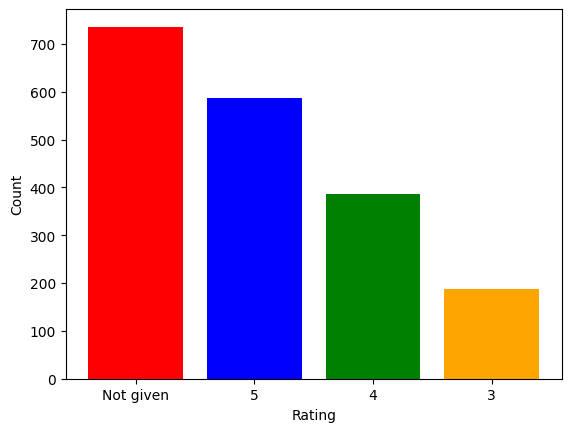

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,food_preparation_time,delivery_time
rating,,,,,,,,
3,188,188,188,188,188,188,188,188
4,386,386,386,386,386,386,386,386
5,588,588,588,588,588,588,588,588
Not given,736,736,736,736,736,736,736,736


In [ ]:
#calculate ratings
rating_counts=df["rating"].value_counts()

# visualize using barplot
plt.bar(rating_counts.index, rating_counts.values, color=["red", "blue", "green", "orange"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#using groupby method we can see the number counts
df.groupby("rating").count()

#### Observations:
The most common value is "No rating" with 736 occurrences, while the least frequent numeric rating is 3, which appears 188 times. This indicates a large portion of orders lack a rating.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

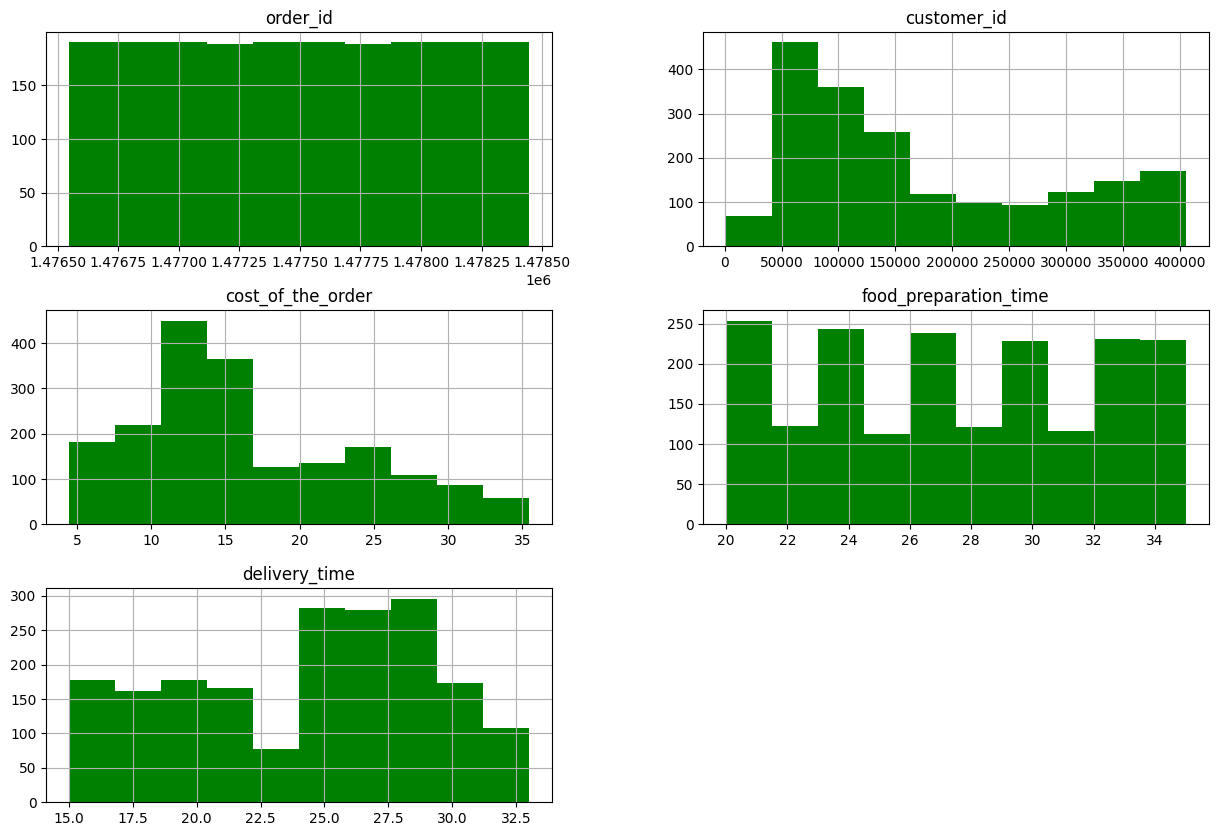

In [ ]:
df.hist(figsize=(15, 10), color='green')
plt.show()


#### Observations:
One of the observations I noticed, cost of order is right skewed. We can see the peak between 10-15 dollar. Based on chart it looks like it's  bimodal distribution - with 2 tops. It might indicate, there are 2 type of buyers - small orders, versus bigger size order maybe for larger groups.

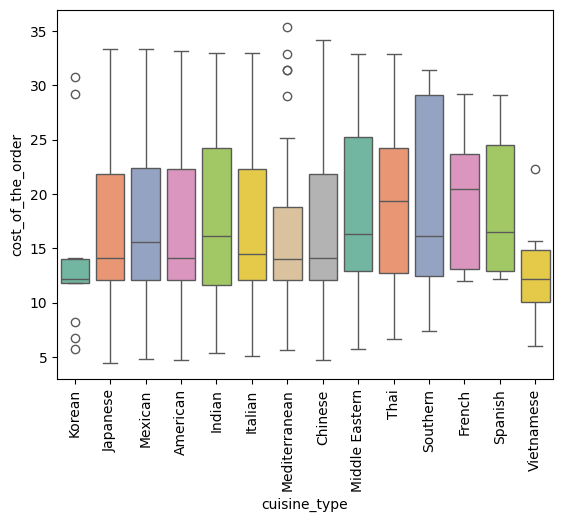

In [ ]:
sns.boxplot(x="cuisine_type", y="cost_of_the_order", data=df, palette="Set2")
plt.xticks(rotation=90)
plt.show()

#### Observations:
Using boxplot we can see cost of the orders based on cusine type. As we see, among 14 cusine types, French restaurant has the highest mean value. Also, we can see the cheapest cousine among these is Vietnamese. Mediterranean and Korean has extreme outliers, which is outside of usual order costs, for those specific restaurants.

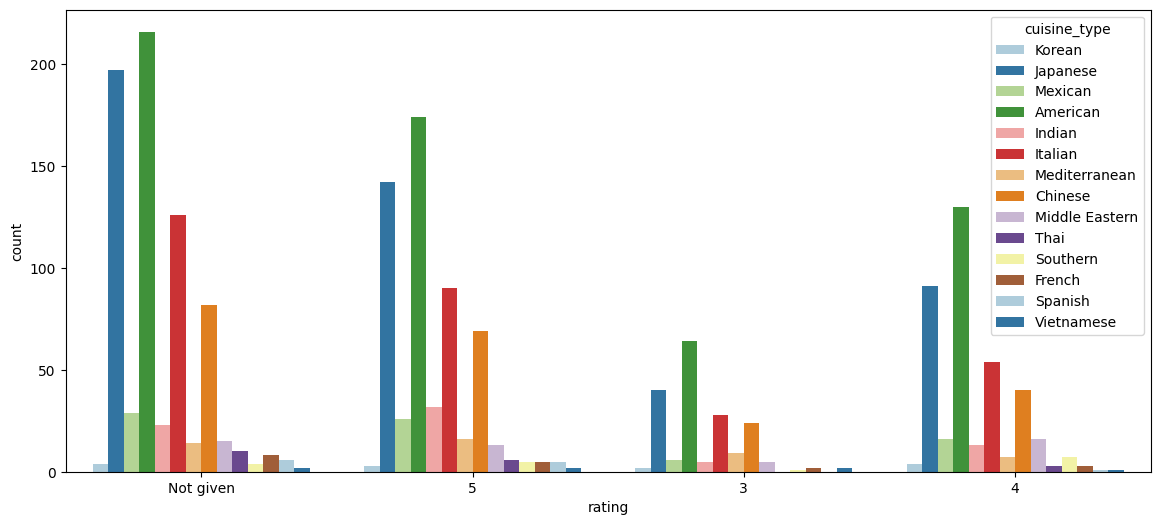

In [ ]:
#Rating Analysis
plt.figure(figsize=(14,6))
sns.countplot(x="rating", hue="cuisine_type", data=df, palette="Paired")
plt.show()


#### Observations:
The plot shows ratings distributed across cuisine types: American cuisine receives the most ratings, followed by Japanese.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:

# using groupby method we can count order based on restaurant name
order_count = df.groupby("restaurant_name").size().reset_index(name="order_count").sort_values("order_count", ascending=False)
print(order_count.head())

               restaurant_name  order_count
136                Shake Shack          219
153          The Meatball Shop          132
21           Blue Ribbon Sushi          119
20   Blue Ribbon Fried Chicken           96
109                       Parm           68


#### Observations:
Top 5 restaurants are:
1. Shake Shack,
2. The Meatball Shop,
3. Blue Ribbon Sushi,
4. Blue Ribbon Fried Chicken,
5. Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

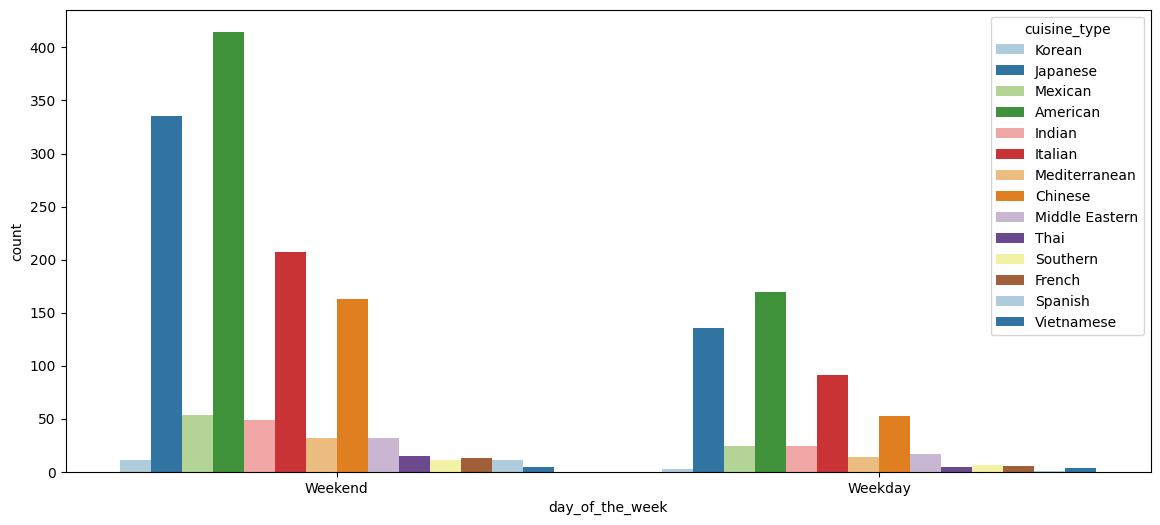

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


In [ ]:
# using countplot hue argument, we can group the data based on order days
plt.figure(figsize=(14,6))
sns.countplot(x="day_of_the_week", hue="cuisine_type", data=df, palette="Paired")
plt.show()

# using filtering method initially selecting orders on weekend
df_weekend = df[df["day_of_the_week"] == "Weekend"]

# count values for top 10 rows
df_weekend['cuisine_type'].value_counts().head(10)

#### Observations:
As wee see both on weekends and weekdays the most prefered order is American and Japenese foods. American cuisine ordered 415 times on weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

, 71% of orders cost under 20$
, 29% of orders cost 20$ or more


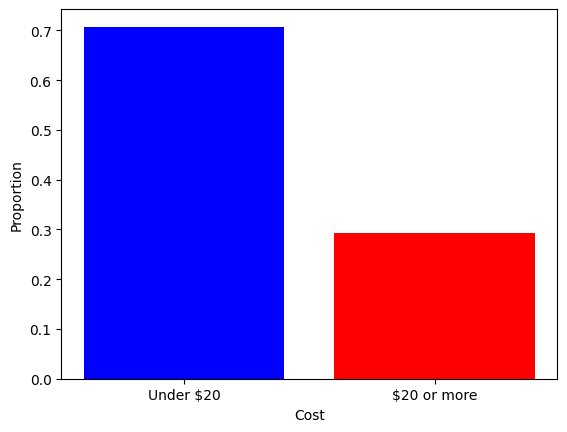

In [ ]:
# Create a dataset of boolean statements. If cost under 20 - True
pcnt_under_20 = df["cost_of_the_order"] < 20
pcnt_over_20 = df["cost_of_the_order"] >= 20

# find the average value of selected True/False statements.
mean_under_20 = pcnt_under_20.mean()
mean_over_20 = pcnt_over_20.mean()

# rounded mean value multiply by 100 to get %
print(f", {round(mean_under_20*100)}%", "of orders cost under 20$")
print(f", {round(mean_over_20*100)}%", "of orders cost 20$ or more")

# plot data using bar plot
plt.bar(["Under $20", "$20 or more"], [mean_under_20, mean_over_20], color=["blue", "red"])
plt.xlabel("Cost")
plt.ylabel("Proportion")
plt.show()

#### Observations:

71% of orders cost 20 dollar or more, while the remaining 29% cost less than 20 dollar




### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
mean_delivery = df["delivery_time"].mean()
print(f"The mean order delivery time is {round(mean_delivery)} minutes")

The mean order delivery time is 24 minutes


#### Observations:
The mean delivery time is 24 minutes

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


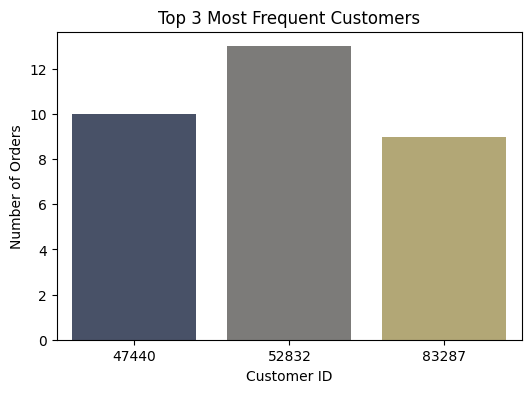

In [ ]:
#creating a dataset of top 3 customers based on order counts
most_freq_customers = df['customer_id'].value_counts().head(3)
print(most_freq_customers)

#plotting the dataset
plt.figure(figsize=(6, 4))
sns.barplot(x=most_freq_customers.index, y=most_freq_customers.values, palette="cividis")
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.title('Top 3 Most Frequent Customers')
plt.show()

#### Observations:
customer_id = 52832 is the top buyer with total of 13 orders.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


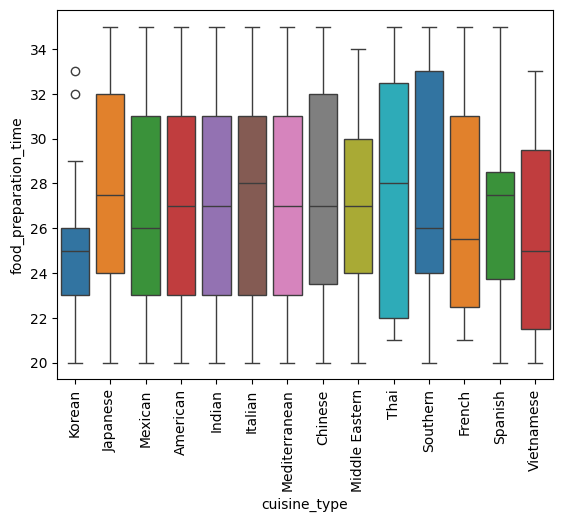

In [ ]:
# boxplot cuisine type vs food preparation time
sns.boxplot(x="cuisine_type", y="food_preparation_time", data=df, palette="tab10")
plt.xticks(rotation=90)
plt.show()

#### Observations:
Among these cuisines, Thai and Italian cuisine average time is higher than the most.

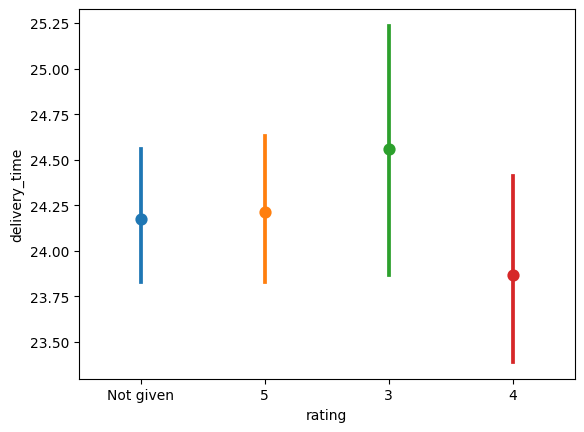

In [ ]:
# Food delivery time vs Rating
sns.pointplot(x="rating", y="delivery_time", data=df, palette="tab10")
plt.show()

#### Observations:
It seems like rating 3 is spreat out - some orders delivered as usual, versus some delivered very slow. Which could be why, they got 3 star feedback.

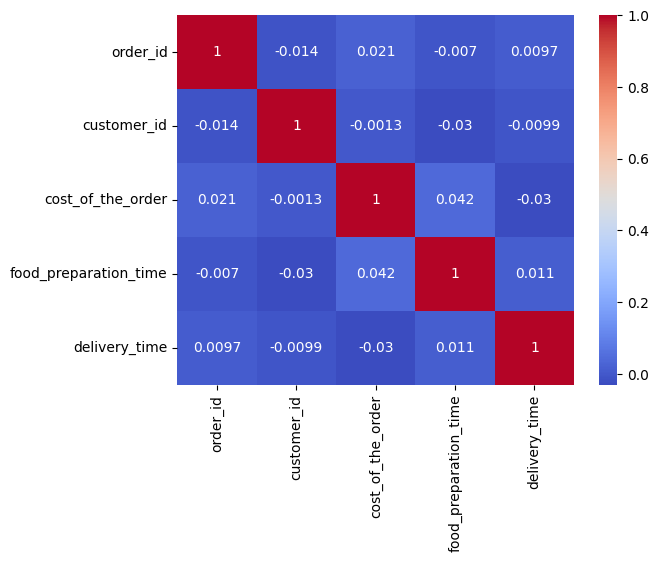

In [ ]:
# create a list of number columns for correlation
corr_list = df.select_dtypes(include=np.number).corr()

#plot correlation list to heatmap
sns.heatmap(corr_list, annot=True, cmap='coolwarm')
plt.show()

#### Observations:
I dont see meaningful correlation between those attributes. Maybe we can point out, food_preparation_time vs cost_of_the_order: as we see 0.042 correlation, which could mean as the cost of the order gets bigger, food preparation time takes longer.

In [ ]:
# using groupby method we can find a sum of the orders based on the restarurant
df.groupby(["restaurant_name"])["cost_of_the_order"].sum().sort_values(ascending = False).head(10)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


#### Observations:
Shake Shack is leading the chart on total of orders with 3579 dollar.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
#replace 'Not given' rating with NaN and change type to float - to process mathematic calculations
df["rating"] = df["rating"].replace("Not given", None).astype(float)

#filter based on rating count over 50
count_filter = df.groupby("restaurant_name")["rating"].count() > 50

#filter based on average value over 4
mean_filter = df.groupby("restaurant_name")["rating"].mean() > 4

# combining 2 boolean series and taking only True conditions on both series
result = count_filter & mean_filter

# using index.tolist() to take only labels
rest_list = result[result].index.tolist()

# print based on condition, if the series is empty notify user
if rest_list == []:
    print("No restaurants fulfilling the criteria")
else:
    print(f"Restaurants fulfilling the criteria: {rest_list}")

Restaurants fulfilling the criteria: ['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop']


#### Observations:
We have 4 restaurants meeting required conditions:
Blue Ribbon Fried Chicken,
Blue Ribbon Sushi,
Shake Shack,
The Meatball Shop.



### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# filter orders based on conditions
over_20 = df[df["cost_of_the_order"] >= 20][["order_id", "cost_of_the_order"]]
over_15 = df[(df["cost_of_the_order"]>5) & (df["cost_of_the_order"]<20)][["order_id", "cost_of_the_order"]]

# calculate revenue for each order
rev_25 = over_20["cost_of_the_order"] * 0.25
rev_15 = over_15["cost_of_the_order"] * 0.15

# calculate the sum of all revenues
sum_rev_25 = round(rev_25.sum())
sum_rev_15 = round(rev_15.sum())

print(f"Company made ${sum_rev_25} from the orders over 20$, and ${sum_rev_15} from the orders over 5$. Company made a total of ${sum_rev_25+sum_rev_15} revenue all together.")



Company made $3689 from the orders over 20$, and $2478 from the orders over 5$. Company made a total of $6167 revenue all together.


Company made 3689 from the orders over 20, and 2478 from the orders over 5. Company made a total of 6167 revenue all together.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# find total time required to process
total_time = df["food_preparation_time"] + df["delivery_time"]

# filter to a boolean series and using total_time[..] take only true values
total_over_60 = total_time[total_time > 60]

# calculate the %
over_60_pct = round((len(total_over_60) / len(total_time)) * 100)
print(f"{over_60_pct}% of orders take more than 60 minutes")

11% of orders take more than 60 minutes


#### Observations:
11% of orders take more than 60 minutes

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

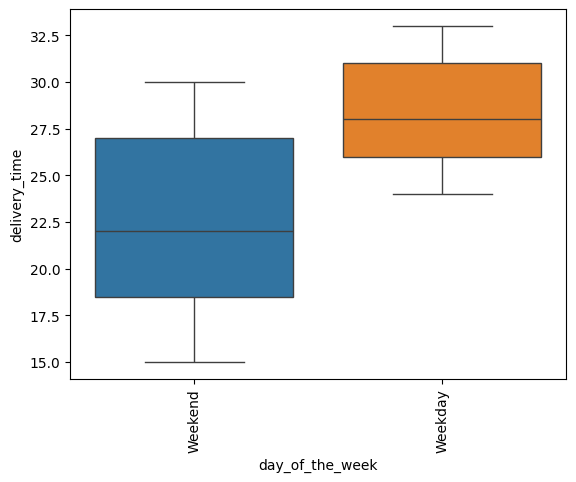

In [ ]:
# Day vs Delivery time

sns.boxplot(x="day_of_the_week", y="delivery_time", data=df, palette="tab10")
plt.xticks(rotation=90)
plt.show()

#### Observations:
1. Median: weekday is slower on average.
Weekend ~22 min vs Weekday ~28 min

2. Box size - weekend box size is bigger than weekday. This indicates orders on weekends can be delivered between ~18min to ~27min. But weekday orders are more consistent and around ~26min-30min.

3. Whiskers - Similarly weekend orders has a huge range from ~15min to ~30min. Weekday we again have tighter range ~24min to ~33min.

Conclusion - Weekday orders are more predictible, but slower. But, weekend orders are very unpredictable, meaning your order can be delivered anytime between ~15min to ~30min.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

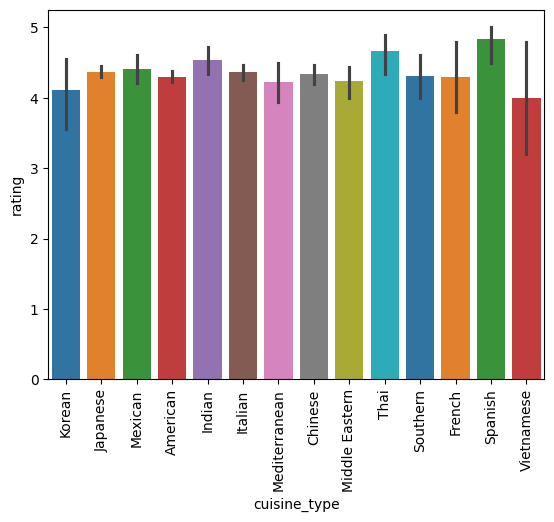

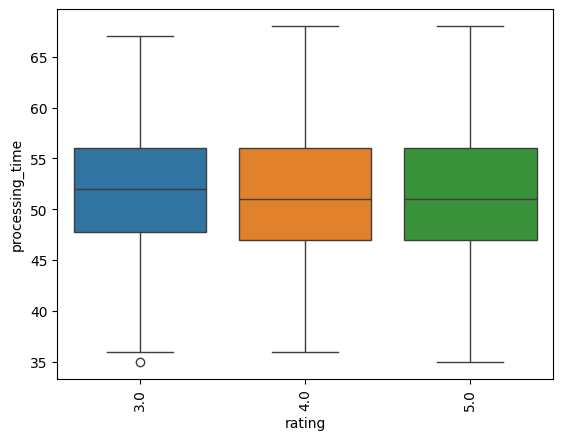

In [ ]:
sns.barplot(x="cuisine_type", y="rating", data=df, palette="tab10")
plt.xticks(rotation=90)
plt.show()

# copying the df dataset for modifications
df_with_process_time = df.copy()
# adding a new column to have a better understanding of processing time
df_with_process_time["processing_time"] = df_with_process_time["food_preparation_time"] + df_with_process_time["delivery_time"]

# validate the dataset
df_with_process_time.describe(include="all").T
df_with_process_time.head()

# boxplot processing time against rating
sns.boxplot(x="rating", y="processing_time", data=df_with_process_time, palette="tab10")
plt.xticks(rotation=90)
plt.show()


#### Observations:
I can see overal customer satisfaction is high. Thai and Spanish reviews are the highest. Meanwhile, Vietnamese cuisine ratings are low as well as confidence interval is high - which means uncertanity based on ratings.
Using box plot, we can confirm lowest rating (3) has higher average processing time than the rest.

### Conclusions:
Platform maintains good quality overall. Maybe we can try to push lower performers over 4.5 levels.

### Recommendations:
1. A huge portion of orders lack ratings — consider post-delivery rating prompt or offering promotions to encourage customer feedback.
2. Low-rated orders should be investigated further — identify whether poor ratings correlate with delivery time, food quality, or specific restaurants, and address root causes accordingly.
3. Spanish and Thai cuisines consistently receive the highest ratings — expanding partnerships with restaurants in these categories could drive higher customer satisfaction.
4. Korean and Vietnamese restaurants show the lowest average ratings — a targeted review of customer complaints, food and packaging quality could help.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/FDS_Project_LearnerNotebook_FullCode.ipynb"

#!find / -name "FDS_Project_LearnerNotebook_FullCode.ipynb" 2>/dev/null

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/FDS_Project_LearnerNotebook_FullCode.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 834568 bytes to /content/drive/MyDrive/Colab Notebooks/FDS_Project_LearnerNotebook_FullCode.html


---